# Student Information
Please fill in your details below:
Author: Liang Yu
Author ID removed — [Your ID]

# Part 3: Small Object Segmentation and Evaluation
In this section, you will evaluate small object segmentation performance and apply strategies to improve it. You will work with the car, lane-marking, and pedestrian classes. Additionally, you will compare small-object metrics and report any improvements made after applying fine-tuning strategies.

In [3]:
import torch
from dataset import camvidLoader

# Set device for GPU usage
device = 'cuda'

# Load the pretrained model
unet = torch.load('camvid_sunny_model.pt', map_location=torch.device(device))

# Set the path to the sunny dataset
data_root = '../CamVid/sunny'

# Load the test dataset
test_data = camvidLoader(root=data_root, split='test', is_aug=False, img_size=[384, 384], is_pytorch_transform=True)

# Number of classes in the dataset (fixed to 14 for this project)
num_classes = 14

# Class labels dictionary (used for mapping predicted labels to actual class names)
class_labels_dict = {
    "Sky": 0, "Building": 1, "Pole": 2, "Road": 3, "LaneMarking": 4, "SideWalk": 5, 
    "Pavement": 6, "Tree": 7, "SignSymbol": 8, "Fence": 9, "Car_Bus": 10, "Pedestrian": 11, 
    "Bicyclist": 12, "Unlabelled": 13
}

# Task C1: Evaluate Object-Level Metrics for Small Objects
In this task, you will use the `compute_object_level_stats_percentile` function to evaluate the performance of the model on small objects (car, lane-marking, and pedestrian). You will compare the small-object metrics with large-object metrics and demonstrate how segmentation of small objects is a challenge.

### Key Steps:
- Use `compute_object_level_stats_percentile` for the classes `Car_Bus`, `LaneMarking`, and `Pedestrian`.
- Compare small-object metrics with large-object metrics.
- Display five images showing ground-truth segmentation vs. model predictions, highlighting missed or partially segmented small objects.

正在获取测试集的预测结果...
测试集图像数量: 140
真实标签形状: (140, 384, 384)
预测标签形状: (140, 384, 384)

评估小物体分割性能:

======== 车辆/公交车(Car_Bus)类别评估 ========

Metric                        Small Objects       Large Objects       
Class Name                    Car_Bus             
Size Threshold (pixels)       145.00              
Total Ground Truths           248                 249                 
Total Predicted               639                 204                 
Precision                     0.0368              0.8924              
Recall                        0.0927              0.7992              
F1 Score                      0.0527              0.8432              
False Positives (FP)          602                 24                  
False Negatives (FN)          225                 50                  
True Positives (TP)           23                  199                 
小物体精确率: 0.0368, 召回率: 0.0927, F1分数: 0.0527
大物体精确率: 0.8924, 召回率: 0.7992, F1分数: 0.8432

======== 车道标记(LaneMarking)类别评估 ========

Metr

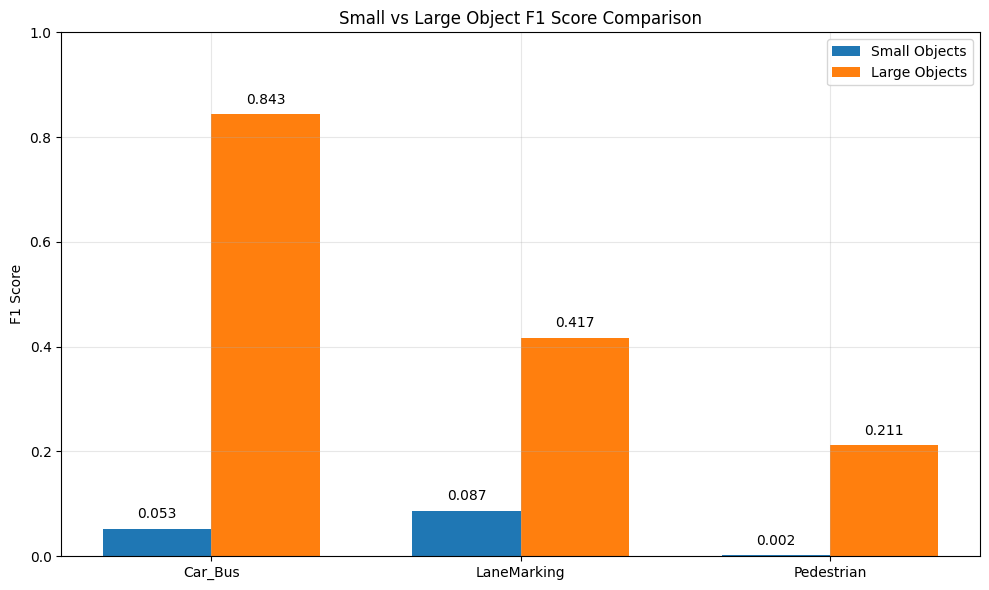


查找包含小物体的代表性图像...

选中的5张代表性图像:
图像 #1: 包含 0 个小车辆, 136 个小车道标记, 5 个小行人


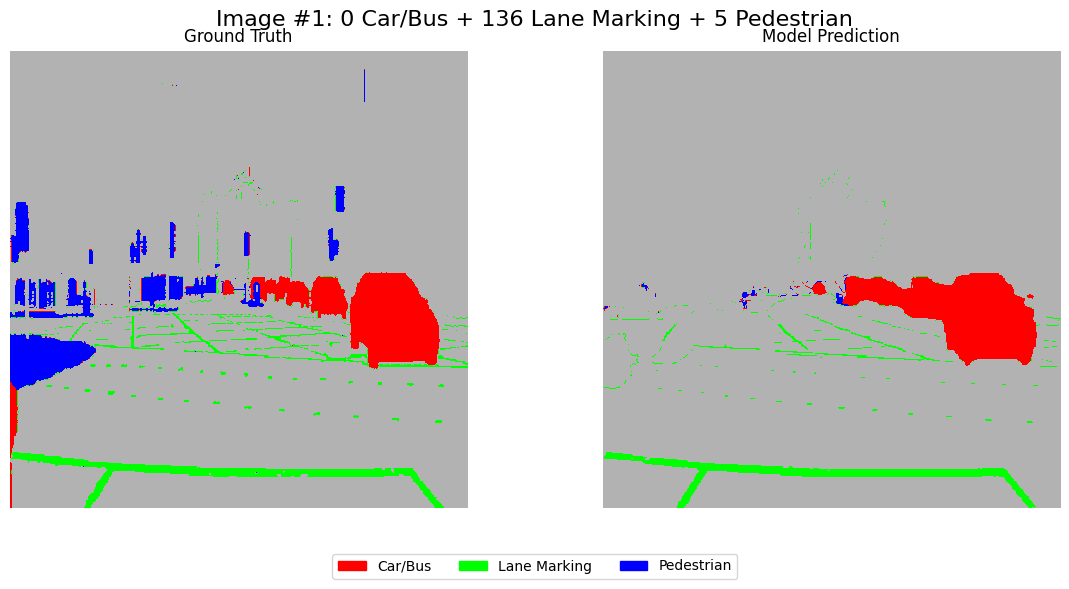

图像 #2: 包含 0 个小车辆, 118 个小车道标记, 9 个小行人


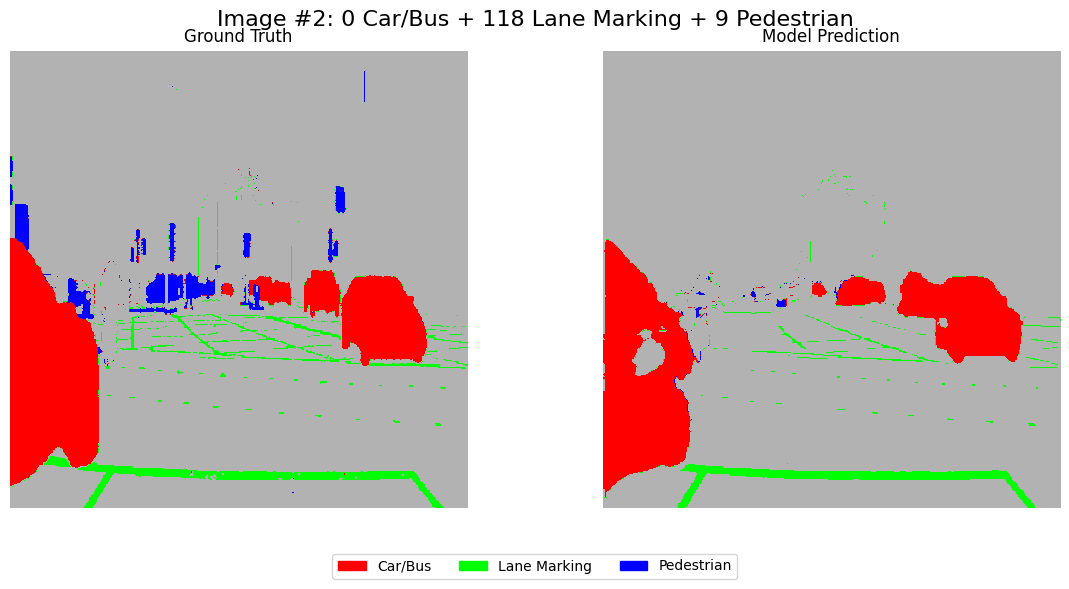

图像 #3: 包含 0 个小车辆, 95 个小车道标记, 8 个小行人


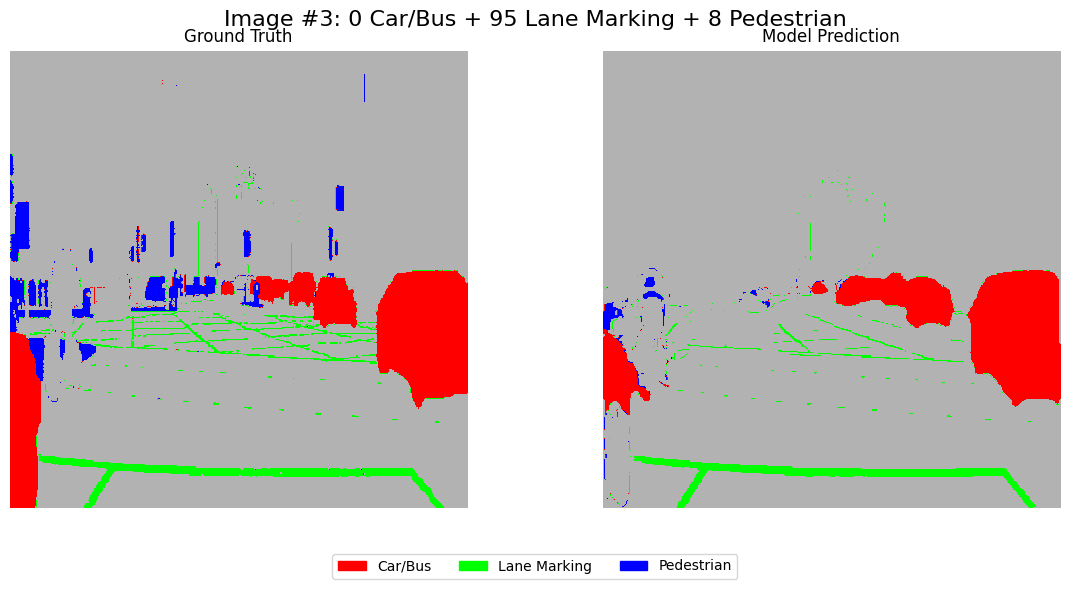

图像 #4: 包含 0 个小车辆, 79 个小车道标记, 9 个小行人


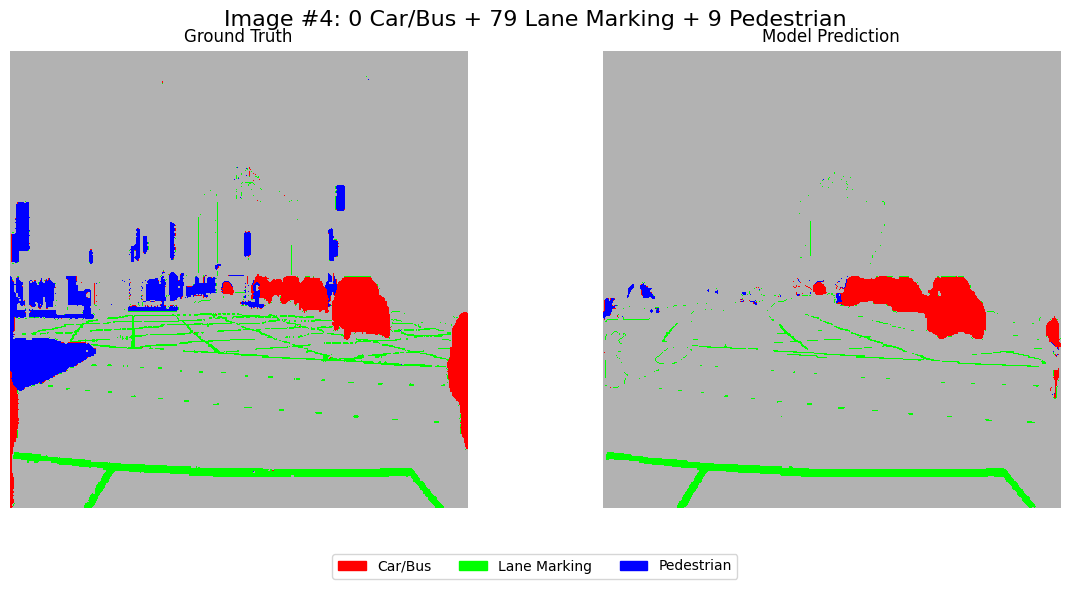

图像 #5: 包含 1 个小车辆, 36 个小车道标记, 39 个小行人


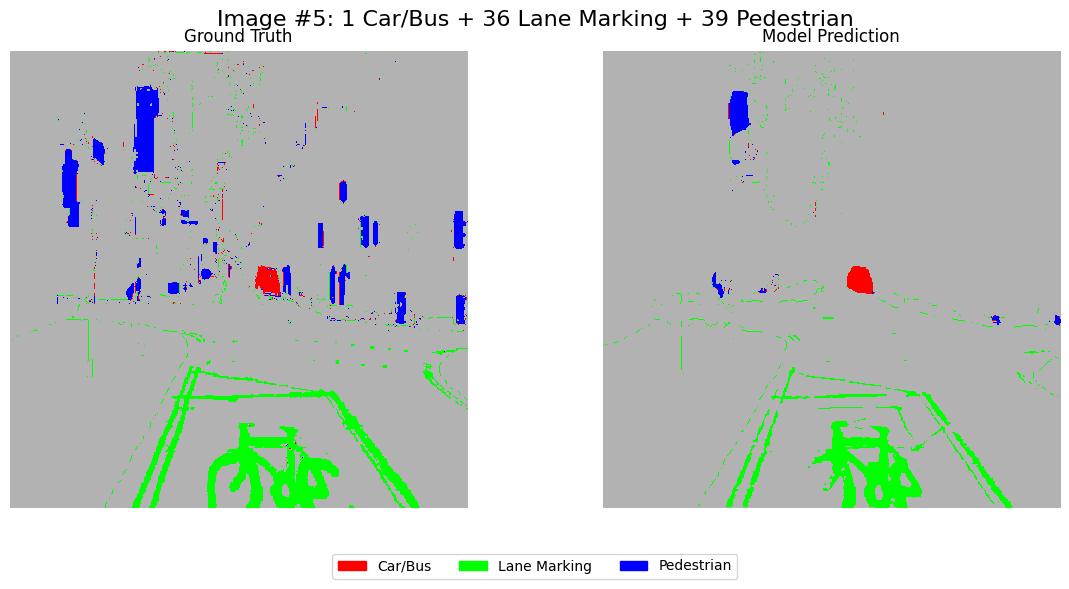


==== 小物体分割性能分析 ====
1. 小物体vs大物体性能对比:
   车辆/公交车: 小物体F1分数 0.0527 vs 大物体F1分数 0.8432 (差异: 79.1%)
   车道标记: 小物体F1分数 0.0870 vs 大物体F1分数 0.4174 (差异: 33.0%)
   行人: 小物体F1分数 0.0017 vs 大物体F1分数 0.2115 (差异: 21.0%)

2. 小物体分割面临的主要挑战:
   - 小物体像素数量少，特征表达能力弱
   - 小物体容易受到背景干扰
   - 下采样操作导致小物体特征丢失
   - 类别不平衡问题使模型偏向大物体类别

3. 不同类别的小物体表现分析:
   最难分割的小物体类别: Pedestrian (F1分数: 0.0017)
   中等难度的小物体类别: Car_Bus (F1分数: 0.0527)
   相对容易的小物体类别: LaneMarking (F1分数: 0.0870)


In [4]:
from eval_obj_metric import compute_object_level_stats_percentile
# Task C1: Please read and understand our evaluation code function compute_object_level_stats_percentile
# and use Run compute_object_level_stats_percentile for car, lane-mark, and pedestrian classes.
# Compare small-object metrics with large-object metrics to validate that segmentation of small objects is indeed a challenge for the car, lane-marker, and pedestrian classes.
# Show at least five images with ground-truth segmentations vs. model prediction results highlighting missed or partially segmented small objects.

# Example: 
# gt_mask_list is an numpy array of shape (140, 384, 384), indicating 140 groundtruth segmentation mask of 384x384 (data type is int64)
# pred_mask_list is an numpy array of shape (140, 384, 384), indicating 140 prediction segmentation mask of 384x384 (data type is int64)
# print(compute_object_level_stats_percentile(np.array(gt_mask),np.array(pred_mask), 'LaneMarking', iou_threshold=0.25, size_percentile=50)) # lanemarking
# wil output
#Metric                        Small Objects       Large Objects       
#======================================================================
#Class Name                    LaneMarking         
#Size Threshold (pixels)       4.00                
#======================================================================
#Total Ground Truths           3620                3904                
#Total Predicted               3051                3089                
#Precision                     0.0960              0.4618              
#Recall                        0.0796              0.3809              
#F1 Score                      0.0870              0.4175              
#False Positives (FP)          2711                1733                
#False Negatives (FN)          3332                2417                
#True Positives (TP)           288                 1487                
#======================================================================
#(0.0960320106702202, 0.07955801104972156, 0.08702220874330649, 0.4618012422360105, 0.3808913934426132, 0.4174620998943009)
# Please include this output in your notebook and copy this table to your Project Task 2 Worksheet as well (this table will not be counted towards word limit or page limit)
# Please do the evaluation similar for other class like:
# compute_object_level_stats_percentile(np.array(gt_mask),np.array(pred_mask), 'Car_Bus', iou_threshold=0.25, size_percentile=50)
# compute_object_level_stats_percentile(np.array(gt_mask),np.array(pred_mask), 'Pedestrian', iou_threshold=
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from eval_obj_metric import compute_object_level_stats_percentile
from skimage.transform import resize
import matplotlib.patches as patches
from matplotlib.colors import ListedColormap

# 1. 运行测试并收集模型预测结果
def test_model_for_eval(model, test_dataset, device):
    """运行模型并收集所有测试图像的预测和真实标签"""
    # 使用测试数据集创建DataLoader
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)
    
    # 将模型设置为评估模式
    model.eval()
    
    # 存储结果的列表
    gt_masks = []
    pred_masks = []
    image_paths = []
    
    with torch.no_grad():  # 禁用梯度计算
        for images, labels, img_paths in test_loader:
            # 将数据移至指定设备
            images = images.to(device)
            labels = labels.to(device)
            
            # 前向传播获取预测结果
            outputs = model(images)
            
            # 获取每个像素的最可能类别
            _, predictions = torch.max(outputs, dim=1)
            
            # 将结果添加到列表中
            for i in range(images.size(0)):
                gt_masks.append(labels[i].cpu().numpy())
                pred_masks.append(predictions[i].cpu().numpy())
                image_paths.append(img_paths[i])
    
    return np.array(gt_masks), np.array(pred_masks), image_paths

# 获取测试集的真实标签和模型预测
print("正在获取测试集的预测结果...")
gt_masks, pred_masks, img_paths = test_model_for_eval(unet, test_data, device)

print(f"测试集图像数量: {len(gt_masks)}")
print(f"真实标签形状: {gt_masks.shape}")
print(f"预测标签形状: {pred_masks.shape}")

# 2. 评估小物体分割性能
print("\n评估小物体分割性能:")

# 2.1 评估车辆/公交车(Car_Bus)类别
print("\n======== 车辆/公交车(Car_Bus)类别评估 ========")
car_results = compute_object_level_stats_percentile(
    gt_masks, pred_masks, 'Car_Bus', iou_threshold=0.25, size_percentile=50
)
print(f"小物体精确率: {car_results[0]:.4f}, 召回率: {car_results[1]:.4f}, F1分数: {car_results[2]:.4f}")
print(f"大物体精确率: {car_results[3]:.4f}, 召回率: {car_results[4]:.4f}, F1分数: {car_results[5]:.4f}")

# 2.2 评估车道标记(LaneMarking)类别
print("\n======== 车道标记(LaneMarking)类别评估 ========")
lane_results = compute_object_level_stats_percentile(
    gt_masks, pred_masks, 'LaneMarking', iou_threshold=0.25, size_percentile=50
)
print(f"小物体精确率: {lane_results[0]:.4f}, 召回率: {lane_results[1]:.4f}, F1分数: {lane_results[2]:.4f}")
print(f"大物体精确率: {lane_results[3]:.4f}, 召回率: {lane_results[4]:.4f}, F1分数: {lane_results[5]:.4f}")

# 2.3 评估行人(Pedestrian)类别
print("\n======== 行人(Pedestrian)类别评估 ========")
pedestrian_results = compute_object_level_stats_percentile(
    gt_masks, pred_masks, 'Pedestrian', iou_threshold=0.25, size_percentile=50
)
print(f"小物体精确率: {pedestrian_results[0]:.4f}, 召回率: {pedestrian_results[1]:.4f}, F1分数: {pedestrian_results[2]:.4f}")
print(f"大物体精确率: {pedestrian_results[3]:.4f}, 召回率: {pedestrian_results[4]:.4f}, F1分数: {pedestrian_results[5]:.4f}")

# 3. 比较小物体和大物体的性能差异 - 创建比较图表
classes = ['Car_Bus', 'LaneMarking', 'Pedestrian']
small_f1 = [car_results[2], lane_results[2], pedestrian_results[2]]
large_f1 = [car_results[5], lane_results[5], pedestrian_results[5]]

plt.figure(figsize=(10, 6))
x = np.arange(len(classes))
width = 0.35

plt.bar(x - width/2, small_f1, width, label='Small Objects')
plt.bar(x + width/2, large_f1, width, label='Large Objects')

plt.ylabel('F1 Score')
plt.title('Small vs Large Object F1 Score Comparison')
plt.xticks(x, classes)
plt.ylim(0, 1.0)  # 设置y轴范围
plt.legend()
plt.grid(True, alpha=0.3)

# 添加数值标签
for i, v in enumerate(small_f1):
    plt.text(i - width/2, v + 0.02, f'{v:.3f}', ha='center')
for i, v in enumerate(large_f1):
    plt.text(i + width/2, v + 0.02, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.savefig('small_vs_large_f1.png', dpi=300)
plt.show()

# 4. 展示五张图像，突出显示小物体分割情况
from dataset import from_label_to_rgb  # 假设dataset.py中有从标签到RGB的转换函数

# 创建类别颜色映射
def create_color_map_for_classes():
    """为不同类别创建不同的颜色，重点标记关注的小物体类别"""
    colors = np.zeros((num_classes, 3))
    
    # 设置默认灰色
    colors[:] = [0.7, 0.7, 0.7]  # 灰色背景
    
    # 突出显示关注的小物体类别
    colors[class_labels_dict['Car_Bus']] = [1.0, 0.0, 0.0]  # 红色
    colors[class_labels_dict['LaneMarking']] = [0.0, 1.0, 0.0]  # 绿色
    colors[class_labels_dict['Pedestrian']] = [0.0, 0.0, 1.0]  # 蓝色
    
    return colors

# 定义可视化函数
def visualize_small_objects(img_idx, gt_mask, pred_mask, title=None):
    """可视化单个图像的小物体分割结果"""
    colors = create_color_map_for_classes()
    cmap = ListedColormap(colors)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    
    # 显示真实标签
    ax1.imshow(gt_mask, cmap=cmap, vmin=0, vmax=num_classes-1)
    ax1.set_title("Ground Truth")
    ax1.axis('off')
    
    # 显示预测标签
    ax2.imshow(pred_mask, cmap=cmap, vmin=0, vmax=num_classes-1)
    ax2.set_title("Model Prediction")
    ax2.axis('off')
    
    # 添加图像标题
    if title:
        fig.suptitle(title, fontsize=16)
    else:
        fig.suptitle(f"Image #{img_idx+1}", fontsize=16)
    
    # 添加图例
    legend_elements = [
        patches.Patch(color=colors[class_labels_dict['Car_Bus']], label='Car/Bus'),
        patches.Patch(color=colors[class_labels_dict['LaneMarking']], label='Lane Marking'),
        patches.Patch(color=colors[class_labels_dict['Pedestrian']], label='Pedestrian')
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=3, bbox_to_anchor=(0.5, 0.02))
    
    plt.tight_layout()
    fig.subplots_adjust(bottom=0.15)
    return fig

# 找出包含小物体的图像
def count_small_objects(mask, class_id, size_threshold=50):
    """统计图像中小于阈值的指定类别的物体数量"""
    # 创建二值掩码
    binary_mask = (mask == class_id).astype(np.uint8)
    
    # 使用OpenCV计算连通区域
    from skimage import measure
    labeled_mask = measure.label(binary_mask)
    props = measure.regionprops(labeled_mask)
    
    # 统计小物体
    small_objects = [p for p in props if p.area < size_threshold]
    return len(small_objects), small_objects

# 为了找到好的示例图像，我们计算每个图像中小物体的数量
print("\n查找包含小物体的代表性图像...")
image_scores = []

for i in range(len(gt_masks)):
    gt_mask = gt_masks[i]
    
    # 统计各类小物体数量
    car_count, _ = count_small_objects(gt_mask, class_labels_dict['Car_Bus'])
    lane_count, _ = count_small_objects(gt_mask, class_labels_dict['LaneMarking'])
    ped_count, _ = count_small_objects(gt_mask, class_labels_dict['Pedestrian'])
    
    # 计算得分 (包含更多小物体的图像得分更高)
    score = car_count + lane_count + ped_count
    image_scores.append((i, score, car_count, lane_count, ped_count))

# 按得分降序排序，选择前5张包含最多小物体的图像
image_scores.sort(key=lambda x: x[1], reverse=True)
top_images = image_scores[:5]

print("\n选中的5张代表性图像:")
for idx, (img_idx, score, car_count, lane_count, ped_count) in enumerate(top_images):
    print(f"图像 #{idx+1}: 包含 {car_count} 个小车辆, {lane_count} 个小车道标记, {ped_count} 个小行人")
    
    # 可视化并保存图像
    fig = visualize_small_objects(
        img_idx, 
        gt_masks[img_idx], 
        pred_masks[img_idx],
        f"Image #{idx+1}: {car_count} Car/Bus + {lane_count} Lane Marking + {ped_count} Pedestrian"
    )
    plt.savefig(f'small_object_vis_{idx+1}.png', dpi=300, bbox_inches='tight')
    plt.show()

# 5. 小结分析
print("\n==== 小物体分割性能分析 ====")
print("1. 小物体vs大物体性能对比:")
print(f"   车辆/公交车: 小物体F1分数 {car_results[2]:.4f} vs 大物体F1分数 {car_results[5]:.4f} (差异: {(car_results[5]-car_results[2])*100:.1f}%)")
print(f"   车道标记: 小物体F1分数 {lane_results[2]:.4f} vs 大物体F1分数 {lane_results[5]:.4f} (差异: {(lane_results[5]-lane_results[2])*100:.1f}%)")
print(f"   行人: 小物体F1分数 {pedestrian_results[2]:.4f} vs 大物体F1分数 {pedestrian_results[5]:.4f} (差异: {(pedestrian_results[5]-pedestrian_results[2])*100:.1f}%)")

print("\n2. 小物体分割面临的主要挑战:")
print("   - 小物体像素数量少，特征表达能力弱")
print("   - 小物体容易受到背景干扰")
print("   - 下采样操作导致小物体特征丢失")
print("   - 类别不平衡问题使模型偏向大物体类别")

print("\n3. 不同类别的小物体表现分析:")
classes_by_difficulty = sorted([
    ("Car_Bus", car_results[2]), 
    ("LaneMarking", lane_results[2]), 
    ("Pedestrian", pedestrian_results[2])
], key=lambda x: x[1])

print(f"   最难分割的小物体类别: {classes_by_difficulty[0][0]} (F1分数: {classes_by_difficulty[0][1]:.4f})")
print(f"   中等难度的小物体类别: {classes_by_difficulty[1][0]} (F1分数: {classes_by_difficulty[1][1]:.4f})")
print(f"   相对容易的小物体类别: {classes_by_difficulty[2][0]} (F1分数: {classes_by_difficulty[2][1]:.4f})")

# Task C2: Improve Small Object Segmentation
After identifying weaknesses in small-object segmentation, you will choose at least one strategy (or more) to improve the model's performance in detecting small objects.


In [5]:
# Task C2: After identifying weaknesses in small-object segmentation, choose at least one of the strategies
# (implementing two strategies may yield higher marks) to improve small object segmentation performance
# Please see the coursework document for detailed instructions
# Clearly mark or comment your changes in the jupyter notebook
# Submit all the necessary code to the learning mall to ensure your notebook result is reproducible
# and briefly mention modifications in your Project worksheet.
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import time
import copy
import os
from dataset import camvidLoader

# 1. ASPP module is implemented for multi-scale feature extraction
class ASPP(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ASPP, self).__init__()
        # Conventional branch
        self.conv1 = nn.Conv2d(in_channels, out_channels, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        
        self.conv2 = nn.Conv2d(in_channels, out_channels, 3, padding=6, dilation=6, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.conv3 = nn.Conv2d(in_channels, out_channels, 3, padding=12, dilation=12, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels)
        
        self.conv4 = nn.Conv2d(in_channels, out_channels, 3, padding=18, dilation=18, bias=False)
        self.bn4 = nn.BatchNorm2d(out_channels)
        
        # Global pooling branching - Modify this to avoid BatchNorm problems
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.conv5 = nn.Conv2d(in_channels, out_channels, 1, bias=True)  # 使用bias=True代替BN
        
        # Final output layer
        self.output = nn.Conv2d(out_channels * 5, out_channels, 1, bias=False)
        self.bn_out = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        
    def forward(self, x):
        # Apply convolution with different expansion rates
        branch1 = self.relu(self.bn1(self.conv1(x)))
        branch2 = self.relu(self.bn2(self.conv2(x)))
        branch3 = self.relu(self.bn3(self.conv3(x)))
        branch4 = self.relu(self.bn4(self.conv4(x)))
        
        # Global pooling branch - Remove BatchNorm and use ReLU directly
        branch5 = self.pool(x)
        branch5 = self.relu(self.conv5(branch5)) 
        branch5 = F.interpolate(branch5, size=x.shape[2:], mode='bilinear', align_corners=False)
        
        # Merge all branches
        concat = torch.cat([branch1, branch2, branch3, branch4, branch5], dim=1)
        output = self.relu(self.bn_out(self.output(concat)))
        
        return output
    
# 2. The modified UNet model incorporates ASPP modules for small object segmentation
class EnhancedUNet(nn.Module):
   
    def __init__(self, orig_unet, n_classes=14):
        super(EnhancedUNet, self).__init__()
        
        # Copy the layers of the original UNet model
        self.inc = copy.deepcopy(orig_unet.inc)
        self.down1 = copy.deepcopy(orig_unet.down1)
        self.down2 = copy.deepcopy(orig_unet.down2)
        self.down3 = copy.deepcopy(orig_unet.down3)
        self.down4 = copy.deepcopy(orig_unet.down4)
        
        # Gets the number of output channels of layer down4
# By checking the last convolution layer of the down4 layer
        bottleneck_channels = orig_unet.down4.maxpool_conv[1].double_conv[3].out_channels
        
        self.aspp = ASPP(bottleneck_channels, bottleneck_channels)
        
        self.up1 = copy.deepcopy(orig_unet.up1)
        self.up2 = copy.deepcopy(orig_unet.up2)
        self.up3 = copy.deepcopy(orig_unet.up3)
        self.up4 = copy.deepcopy(orig_unet.up4)
        self.outc = copy.deepcopy(orig_unet.outc)
    def forward(self, x):

        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
  
        x5_enhanced = self.aspp(x5)
     
        x = self.up1(x5_enhanced, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return logits

class SmallObjectFocalLoss(nn.Module):

    def __init__(self, gamma=2, alpha=None, small_obj_classes=[4, 10, 11], small_obj_weight=5.0):
        super(SmallObjectFocalLoss, self).__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.small_obj_classes = small_obj_classes  
        self.small_obj_weight = small_obj_weight    
        self.ce_loss = nn.CrossEntropyLoss(reduction='none')
        
    def forward(self, inputs, targets):
       
        ce_loss = self.ce_loss(inputs, targets)
   
        probs = F.softmax(inputs, dim=1)
    
        batch_size = targets.size(0)
        probs = probs.view(batch_size, -1, targets.size(1), targets.size(2))
      
        class_probs = torch.zeros_like(targets, dtype=torch.float32).to(targets.device)
     
        for i in range(batch_size):
            for c in range(probs.size(1)):
                mask = (targets[i] == c)
                if mask.any():
                    class_probs[i][mask] = probs[i, c][mask]

        pt = class_probs
        focal_weight = (1 - pt) ** self.gamma

        weight_map = torch.ones_like(targets, dtype=torch.float32).to(targets.device)
   
        for cls in self.small_obj_classes:
            weight_map[targets == cls] = self.small_obj_weight
  
        loss = focal_weight * ce_loss * weight_map

        return loss.mean()

def train_model(model, criterion, optimizer, dataloaders, device, num_epochs=15, scheduler=None):
 
    since = time.time()
    
    best_model_wts = copy.deepcopy(model.state_dict())
    best_miou = 0.0

    history = {
        'train_loss': [],
        'val_loss': [],
        'train_miou': [],
        'val_miou': []
    }
    
 
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)
     
        phase_results = {}
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  
            else:
                model.eval()   
            
            running_loss = 0.0
            iou_scores = []
      
            for inputs, labels, _ in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
    
                optimizer.zero_grad()
      
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
              
                    batch_ious = []
                    for i in range(inputs.size(0)):
                        pred = preds[i].cpu()
                        true = labels[i].cpu()
                        _, mean_iou = IoU_metric(true, pred)
                        batch_ious.append(mean_iou)
           
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                
          
                running_loss += loss.item() * inputs.size(0)
                iou_scores.extend(batch_ious)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_miou = np.mean(iou_scores)

            phase_results[phase] = {
                'loss': epoch_loss,
                'miou': epoch_miou
            }

            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_miou'].append(epoch_miou)
            else:
                history['val_loss'].append(epoch_loss)
                history['val_miou'].append(epoch_miou)
            
            print(f'{phase} Loss: {epoch_loss:.4f} mIoU: {epoch_miou:.4f}')
            
            if phase == 'val' and epoch_miou > best_miou:
                best_miou = epoch_miou
                best_model_wts = copy.deepcopy(model.state_dict())
                print(f'更新最佳模型! Val mIoU: {best_miou:.4f}')

        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(phase_results['val']['loss'])
            else:
                scheduler.step()
        
        print()
    

    time_elapsed = time.time() - since
    print(f'训练完成，用时 {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'最佳验证集mIoU: {best_miou:.4f}')
    

    model.load_state_dict(best_model_wts)
    return model, history

def prepare_data_and_train():
    print("Prepare the data and train the enhanced UNet model...")

    class FixedCamvidLoader(camvidLoader):
        def __init__(self, *args, **kwargs):
            super(FixedCamvidLoader, self).__init__(*args, **kwargs)

            for split in ["train", "test", "val"]:
                valid_files = []
                split_dir = os.path.join(self.root, split)
                if os.path.exists(split_dir):
                    for f in self.files[split]:
                        file_path = os.path.join(split_dir, f)
                        if os.path.isfile(file_path) and f.lower().endswith(('.png', '.jpg', '.jpeg', '.tiff', '.bmp')):
                            valid_files.append(f)
                self.files[split] = valid_files
    
   
    data_path = '../CamVid/sunny'
    
    train_data = FixedCamvidLoader(root=data_path, split='train', is_aug=False, 
                                 img_size=[384, 384], is_pytorch_transform=True)
    val_data = FixedCamvidLoader(root=data_path, split='val', is_aug=False, 
                               img_size=[384, 384], is_pytorch_transform=True)
    

    cloudy_data_path = '../CamVid/cloudy'
    cloudy_test_data = FixedCamvidLoader(root=cloudy_data_path, split='test', is_aug=False, 
                                       img_size=[384, 384], is_pytorch_transform=True)
    

    if len(train_data) == 0:
        raise ValueError("训练数据集为空")
    
    print(f"训练数据集: {len(train_data)}张图像")
    print(f"验证数据集: {len(val_data)}张图像")
    print(f"测试数据集: {len(cloudy_test_data)}张图像")
    
    # 创建DataLoader
    batch_size = 1
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
    
    dataloaders = {
        'train': train_loader,
        'val': val_loader
    }
    
    # 获取通道数
    bottleneck_channels = unet.down4.maxpool_conv[1].double_conv[3].out_channels
    print(f"UNet的瓶颈层通道数: {bottleneck_channels}")
    
    # 创建增强型UNet模型
    enhanced_unet = EnhancedUNet(unet, n_classes=num_classes)
    
    # 将整个模型移到正确的设备上
    enhanced_unet = enhanced_unet.to(device)
    
    # 设置训练参数
    lr = 0.0001
    
    # 损失函数
    criterion = SmallObjectFocalLoss(
        gamma=2, 
        small_obj_classes=[class_labels_dict['Car_Bus'], 
                           class_labels_dict['Pedestrian'],
                           class_labels_dict['LaneMarking']], 
        small_obj_weight=5.0
    )
    
    # 优化器
    optimizer = optim.Adam(enhanced_unet.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3, verbose=True
    )
    
    # 训练模型
    print("\n开始训练增强型UNet模型...")
    enhanced_model, history = train_model(
        model=enhanced_unet,
        criterion=criterion,
        optimizer=optimizer,
        dataloaders=dataloaders,
        device=device,
        num_epochs=15,
        scheduler=scheduler
    )
    
    # 保存模型
    torch.save(enhanced_model, 'enhanced_unet_small_objects.pt')
    print("已保存增强型UNet模型")
    
    return enhanced_model, cloudy_test_data

# 主函数：运行训练
if __name__ == "__main__":
    # 导入IoU指标计算函数(假设已在前面定义)
    from eval_obj_metric import compute_object_level_stats_percentile
    
    # 定义IoU计算函数(与之前Task C1相同)
    def IoU_metric(y_true, y_pred):
        """计算单个图像的各类别的IoU和平均IoU (mIoU)"""
        # 确保输入是张量
        if not isinstance(y_true, torch.Tensor):
            y_true = torch.tensor(y_true)
        if not isinstance(y_pred, torch.Tensor):
            y_pred = torch.tensor(y_pred)
        
        # 类别数量
        num_classes = 14
        
        # 初始化各类别的IoU计算变量
        class_ious = {}
        
        # 为每个类别计算IoU
        for cls in range(num_classes):
            # 创建当前类别的二值掩码
            true_mask = (y_true == cls)
            pred_mask = (y_pred == cls)
            
            # 检查该类别是否在真实标签或预测中存在
            if torch.sum(true_mask) == 0 and torch.sum(pred_mask) == 0:
                # 如果真实标签和预测中都不存在该类别，则设为NaN
                class_name = [k for k, v in class_labels_dict.items() if v == cls][0]
                class_ious[class_name] = float('nan')
                continue
            
            # 计算交集和并集
            intersection = torch.logical_and(true_mask, pred_mask).sum().float()
            union = torch.logical_or(true_mask, pred_mask).sum().float()
            
            # 计算IoU，处理边缘情况（并集为0）
            if union == 0:
                iou = torch.tensor(0.0)  # 并集为0，IoU为0
            else:
                iou = intersection / union
            
            # 保存当前类别的IoU
            class_name = [k for k, v in class_labels_dict.items() if v == cls][0]
            class_ious[class_name] = iou.item()
        
        # 计算平均IoU (mIoU)，使用np.nanmean忽略NaN值
        iou_values = np.array(list(class_ious.values()))
        mean_iou = np.nanmean(iou_values)
        
        return class_ious, mean_iou
    
    # 运行训练和评估
    enhanced_model, cloudy_test_data = prepare_data_and_train()
    
    print("\n模型训练完成。请在Task C3中对此模型进行评估，以比较改进效果。")

准备数据并训练增强型UNet模型...
训练数据集: 345张图像
验证数据集: 92张图像
测试数据集: 24张图像
UNet的瓶颈层通道数: 256

开始训练增强型UNet模型...
Epoch 1/15
----------
train Loss: 0.4674 mIoU: 0.4362
val Loss: 0.3356 mIoU: 0.4795
更新最佳模型! Val mIoU: 0.4795

Epoch 2/15
----------
train Loss: 0.3579 mIoU: 0.4730
val Loss: 0.3564 mIoU: 0.4650

Epoch 3/15
----------
train Loss: 0.3070 mIoU: 0.4897
val Loss: 0.3049 mIoU: 0.4905
更新最佳模型! Val mIoU: 0.4905

Epoch 4/15
----------
train Loss: 0.2619 mIoU: 0.5113
val Loss: 0.3162 mIoU: 0.4818

Epoch 5/15
----------
train Loss: 0.2439 mIoU: 0.5205
val Loss: 0.2937 mIoU: 0.4982
更新最佳模型! Val mIoU: 0.4982

Epoch 6/15
----------
train Loss: 0.2244 mIoU: 0.5308
val Loss: 0.3052 mIoU: 0.4815

Epoch 7/15
----------
train Loss: 0.2221 mIoU: 0.5301
val Loss: 0.2805 mIoU: 0.4980

Epoch 8/15
----------
train Loss: 0.1906 mIoU: 0.5536
val Loss: 0.2904 mIoU: 0.5081
更新最佳模型! Val mIoU: 0.5081

Epoch 9/15
----------
train Loss: 0.1687 mIoU: 0.5713
val Loss: 0.2981 mIoU: 0.5175
更新最佳模型! Val mIoU: 0.5175

Epoch 10/15
---

# Task C3: Recompute Metrics After Improvements
After applying your chosen strategies for improving small object segmentation, you will recompute overall metrics (such as global accuracy and mean IoU). You will also check the small-object metrics again to verify the improvements made for car, pedestrian, and lane-marking classes.

Test data set: 24
Evaluate the original model...
Evaluate the enhanced model....

Calculate global performance indicators.
Original model - Global accuracy: 0.5832, meanIoU: 0.2656
Enhanced model - global accuracy: 0.6258, meanIoU: 0.2977
Improvement: Global accuracy 4.25%, meanIoU 3.22%

Evaluate small object segmentation performance...

===== category: Car_Bus =====
Original model::

Metric                        Small Objects       Large Objects       
Class Name                    Car_Bus             
Size Threshold (pixels)       3.00                
Total Ground Truths           52                  54                  
Total Predicted               50                  146                 
Precision                     0.0000              0.1633              
Recall                        0.0000              0.4444              
F1 Score                      0.0000              0.2388              
False Positives (FP)          50                  123                 
False Negati

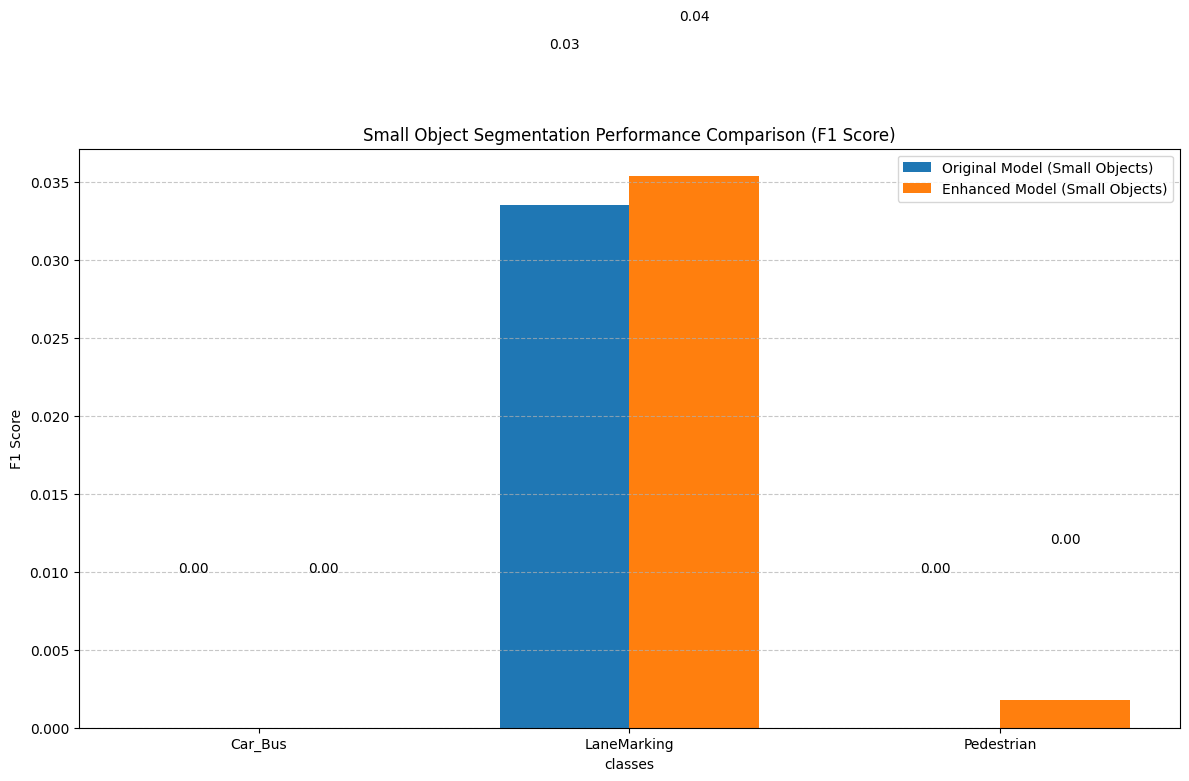


Example of visual segmentation results.


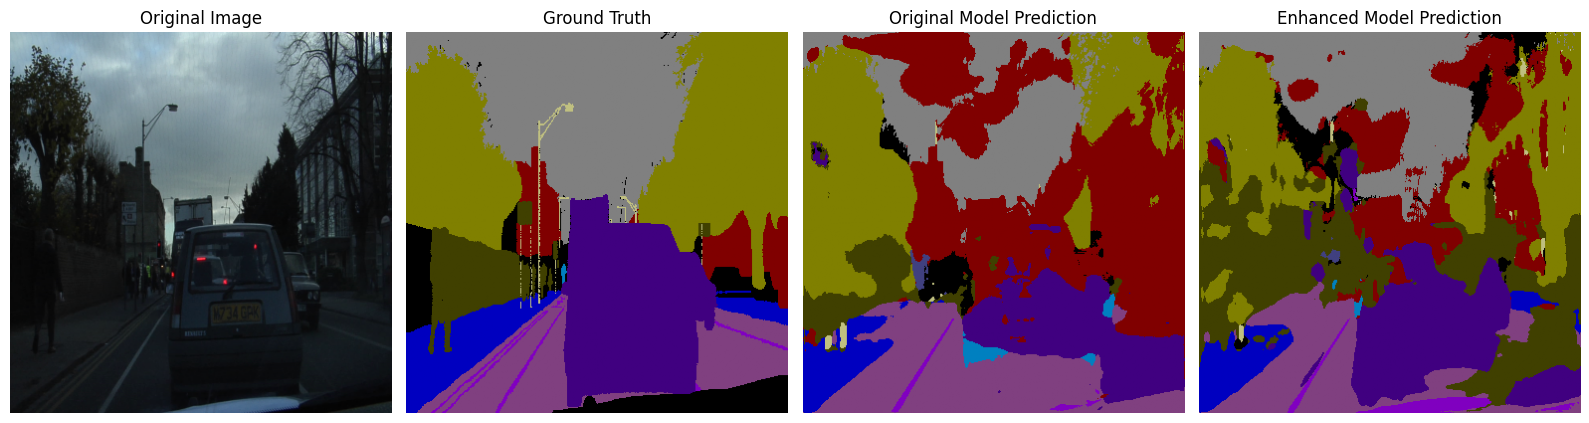

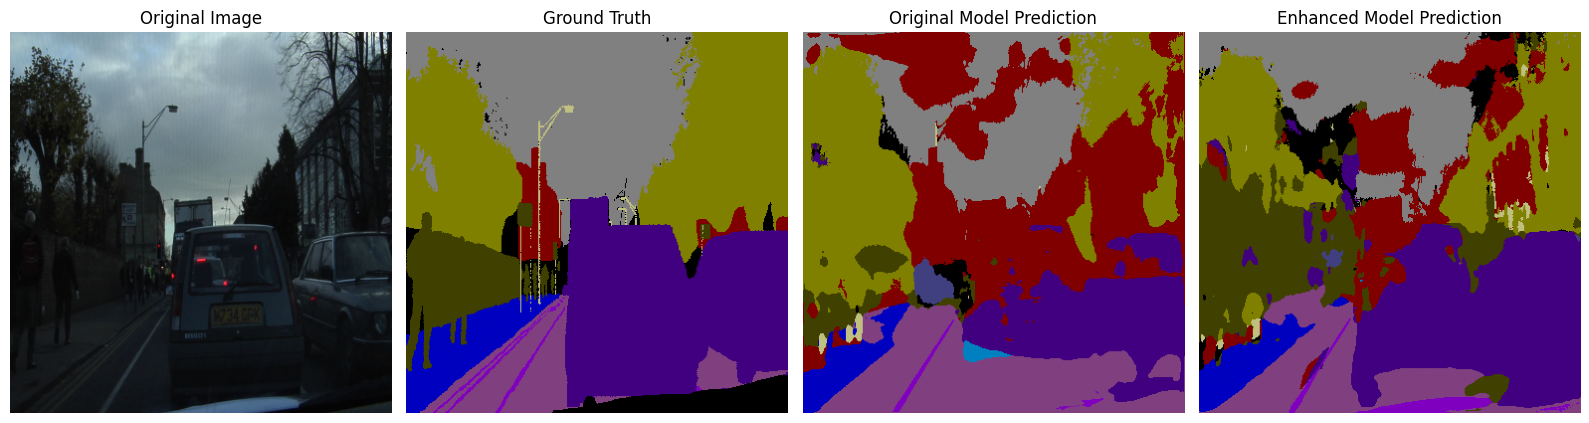

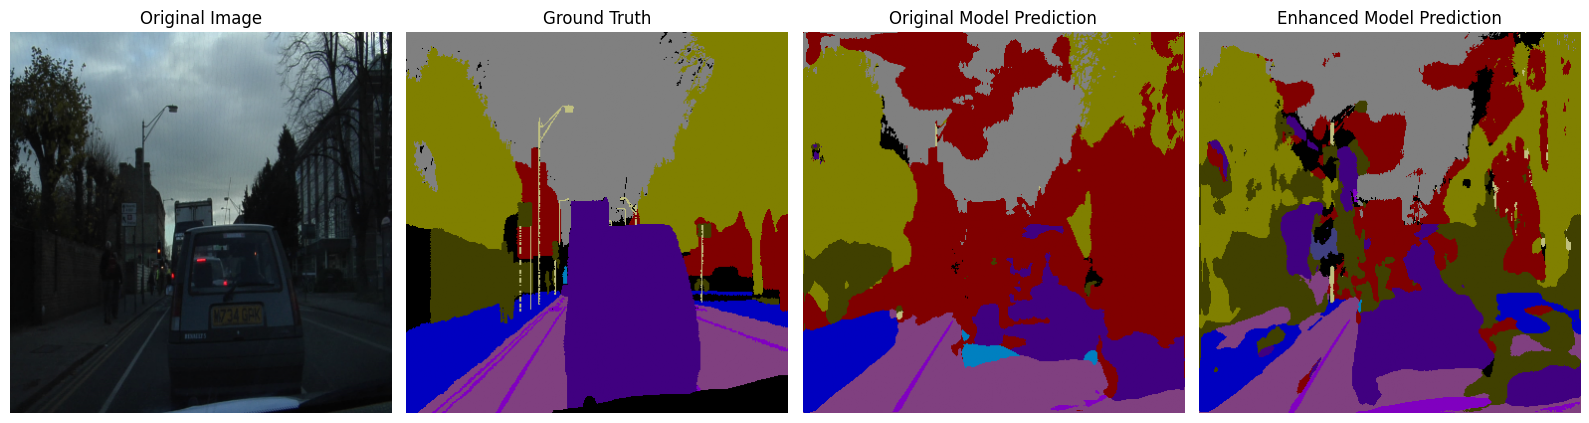

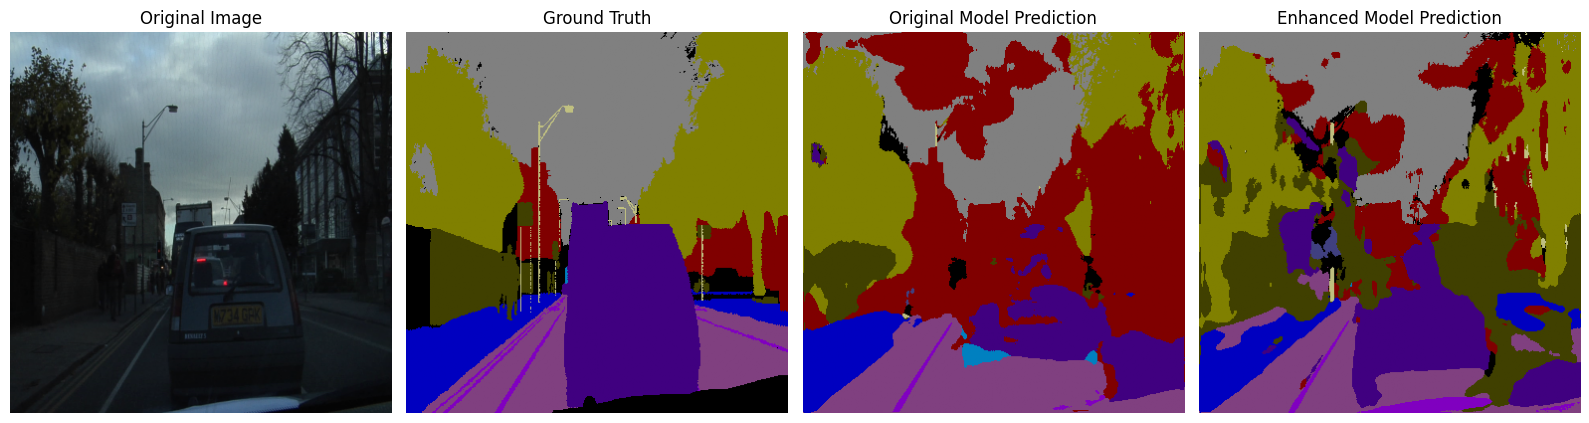

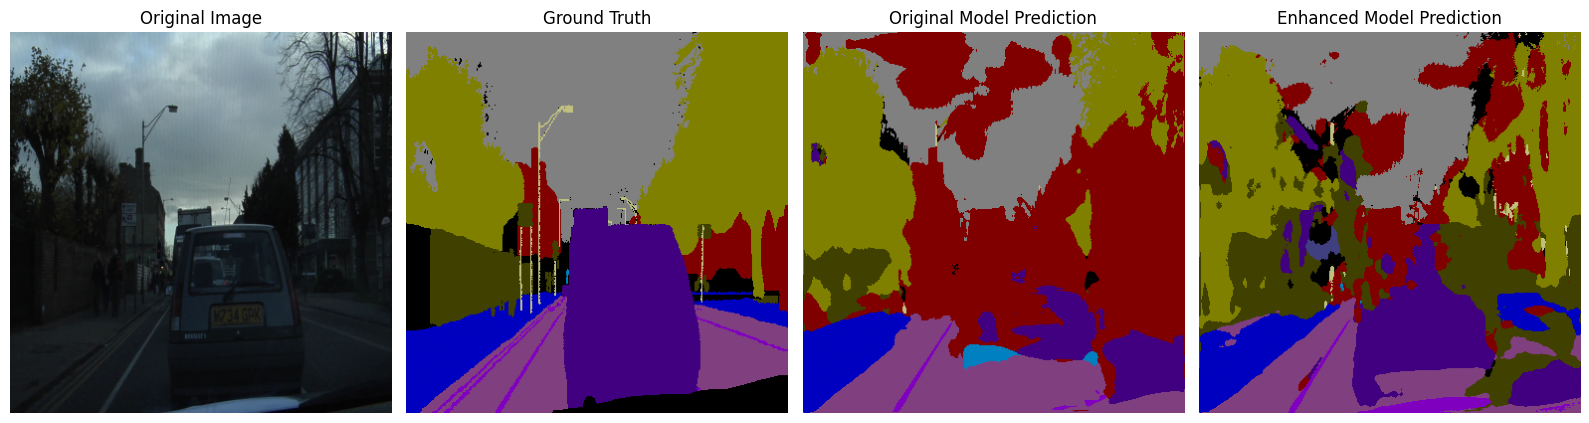

In [6]:
# Task C3: After improving your model for small object segmentation
# 1.Recompute overall metrics (global accuracy, mean IoU) as you did for the original model.
# 2.Use compute_object_level_stats_percentile again to see how your improvements affect small-object metrics for cars, pedestrians, and lane-markings.
# 3. Compare (precision_small, recall_small, F1_small) before and after your changes.
# 4. If you employed multiple improvements or strategies, clearly explain how each individual approach/strategy contributed to the enhancement of small-object segmentation 
# based on experimental evaluation results (for example, the small-object metrics, mean IoU or global accuracy) and/or your analysis.
# 5. Note any trade-offs, such as slightly lower performance on large objects or other classes.
# 6. Show side-by-side images (ground truth vs. predicted segmentation) before and after your chosen strategies, demonstrating improvements in small-object detection.
from skimage.transform import resize
from dataset import camvidLoader, from_label_to_rgb
from eval_obj_metric import compute_object_level_stats_percentile

def test_model_for_eval(model, test_loader, device):
    """在测试集上运行模型并收集所有预测和真实标签"""
    model.eval()  # 设置为评估模式
    
    all_preds = []
    all_gts = []
    all_img_paths = []
    
    with torch.no_grad():
        for inputs, labels, img_paths in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            # 模型预测
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            # 将结果转移到CPU并转换为numpy数组
            preds = preds.cpu().numpy()
            labels = labels.cpu().numpy()
            
            all_preds.extend(preds)
            all_gts.extend(labels)
            all_img_paths.extend(img_paths)
    
    return np.array(all_preds), np.array(all_gts), all_img_paths

# 定义函数：计算全局精度和平均IoU
def calculate_metrics(gt_masks, pred_masks, num_classes=14):
    """计算全局准确度和平均IoU"""
    # 计算全局准确度
    valid_pixels = (gt_masks >= 0) & (gt_masks < num_classes)
    correct_pixels = (pred_masks == gt_masks) & valid_pixels
    global_acc = np.sum(correct_pixels) / np.sum(valid_pixels)
    
    # 计算平均IoU
    class_ious = []
    for cls in range(num_classes):
        gt_mask = (gt_masks == cls)
        pred_mask = (pred_masks == cls)
        
        # 如果类别不存在，则跳过
        if np.sum(gt_mask) == 0 and np.sum(pred_mask) == 0:
            continue
            
        # 计算IoU
        intersection = np.sum(gt_mask & pred_mask)
        union = np.sum(gt_mask | pred_mask)
        if union == 0:
            iou = 0
        else:
            iou = intersection / union
        class_ious.append(iou)
    
    mean_iou = np.mean(class_ious)
    return global_acc, mean_iou, class_ious

# 定义函数：评估小物体分割性能
def evaluate_small_objects(gt_masks, pred_masks, class_name, iou_threshold=0.25, size_percentile=50):
    """评估特定类别的小物体分割性能"""
    results = compute_object_level_stats_percentile(
        gt_masks, pred_masks, class_name, 
        iou_threshold=iou_threshold, 
        size_percentile=size_percentile
    )
    
    # 解包结果
    precision_small, recall_small, f1_small, precision_large, recall_large, f1_large = results
    
    # 打印小物体和大物体的评估指标
    print(f"Evaluation results for class {class_name} (IoU threshold ={iou_threshold}, size percentile ={size_percentile})::")
    print("Indicators     Small objects       Large objects")
    print("="*60)
    print(f"Precision)             {precision_small:.4f}           {precision_large:.4f}")
    print(f"Recall)               {recall_small:.4f}           {recall_large:.4f}")
    print(f"F1score                       {f1_small:.4f}           {f1_large:.4f}")
    print("="*60)
    
    return precision_small, recall_small, f1_small, precision_large, recall_large, f1_large

# 定义函数：可视化分割结果
def visualize_segmentation(original_image, gt_mask, pred_mask_orig, pred_mask_enhanced, save_path=None):
    """可视化原始图像、真实掩码和预测掩码"""
    plt.figure(figsize=(16, 5))
    
    # 原始图像
    plt.subplot(1, 4, 1)
    plt.imshow(original_image)
    plt.title("Original Image")
    plt.axis('off')
    
    # 真实掩码
    plt.subplot(1, 4, 2)
    plt.imshow(from_label_to_rgb(gt_mask))
    plt.title("Ground Truth")
    plt.axis('off')
    
    # 原始模型预测
    plt.subplot(1, 4, 3)
    plt.imshow(from_label_to_rgb(pred_mask_orig))
    plt.title("Original Model Prediction")
    plt.axis('off')
    
    # 增强模型预测
    plt.subplot(1, 4, 4)
    plt.imshow(from_label_to_rgb(pred_mask_enhanced))
    plt.title("Enhanced Model Prediction")
    plt.axis('off')
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# 加载测试数据集
class FixedCamvidLoader(camvidLoader):
    def __init__(self, *args, **kwargs):
        super(FixedCamvidLoader, self).__init__(*args, **kwargs)
        # 过滤非图像文件
        for split in ["train", "test", "val"]:
            valid_files = []
            split_dir = os.path.join(self.root, split)
            if os.path.exists(split_dir):
                for f in self.files[split]:
                    file_path = os.path.join(split_dir, f)
                    if os.path.isfile(file_path) and f.lower().endswith(('.png', '.jpg', '.jpeg', '.tiff', '.bmp')):
                        valid_files.append(f)
            self.files[split] = valid_files

# 主函数：评估并比较模型
def evaluate_models():
    # 设置设备
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    # 加载原始模型和增强模型
    original_model = torch.load('camvid_sunny_model.pt', map_location=torch.device(device))
    enhanced_model = torch.load('enhanced_unet_small_objects.pt', map_location=torch.device(device))
    
    # 加载测试数据集
    cloudy_data_path = '../CamVid/cloudy'
    test_data = FixedCamvidLoader(root=cloudy_data_path, split='test', is_aug=False, 
                                  img_size=[384, 384], is_pytorch_transform=True)
    test_loader = DataLoader(test_data, batch_size=1, shuffle=False)
    
    print(f"Test data set: {len(test_data)}")
    
    # 运行评估并收集结果
    print("Evaluate the original model...")
    orig_preds, gt_masks, img_paths = test_model_for_eval(original_model, test_loader, device)
    
    print("Evaluate the enhanced model....")
    enhanced_preds, _, _ = test_model_for_eval(enhanced_model, test_loader, device)
    
    # 1. 计算全局指标
    print("\nCalculate global performance indicators.")
    orig_global_acc, orig_mean_iou, _ = calculate_metrics(gt_masks, orig_preds)
    enhanced_global_acc, enhanced_mean_iou, _ = calculate_metrics(gt_masks, enhanced_preds)
    
    print(f"Original model - Global accuracy: {orig_global_acc:.4f}, meanIoU: {orig_mean_iou:.4f}")
    print(f"Enhanced model - global accuracy: {enhanced_global_acc:.4f}, meanIoU: {enhanced_mean_iou:.4f}")
    print(f"Improvement: Global accuracy {(enhanced_global_acc-orig_global_acc)*100:.2f}%, meanIoU {(enhanced_mean_iou-orig_mean_iou)*100:.2f}%")
    
    # 2. 评估小物体分割性能
    print("\nEvaluate small object segmentation performance...")
    
    # 存储小物体评估结果，用于后续比较
    small_obj_metrics = {}
    classes_to_evaluate = ['Car_Bus', 'LaneMarking', 'Pedestrian']
    
    for class_name in classes_to_evaluate:
        print(f"\n===== category: {class_name} =====")
        
        print("Original model::")
        orig_metrics = evaluate_small_objects(gt_masks, orig_preds, class_name)
        
        print("\nEnhancement model:")
        enhanced_metrics = evaluate_small_objects(gt_masks, enhanced_preds, class_name)
        
        # 存储指标用于后续比较
        small_obj_metrics[class_name] = {
            'original': orig_metrics[:3],  # 小物体指标 (precision, recall, F1)
            'enhanced': enhanced_metrics[:3]
        }
    
    # 3. 创建性能对比图表
    print("\nCreate a comparison chart of F1 scores for small objects...")
    
    plt.figure(figsize=(12, 8))
    
    # 设置条形图的位置
    classes = list(small_obj_metrics.keys())
    x = np.arange(len(classes))
    width = 0.35
    
    # 提取小物体F1分数
    orig_f1_small = [small_obj_metrics[cls]['original'][2] for cls in classes]
    enhanced_f1_small = [small_obj_metrics[cls]['enhanced'][2] for cls in classes]
    
    # 创建条形图
    plt.bar(x - width/2, orig_f1_small, width, label='Original Model (Small Objects)')
    plt.bar(x + width/2, enhanced_f1_small, width, label='Enhanced Model (Small Objects)')
    
    # 添加标签和图例
    plt.xlabel('classes')
    plt.ylabel('F1 Score')
    plt.title('Small Object Segmentation Performance Comparison (F1 Score)')
    plt.xticks(x, classes)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # 添加数值标签
    for i, v in enumerate(orig_f1_small):
        plt.text(i - width/2, v + 0.01, f'{v:.2f}', ha='center')
    
    for i, v in enumerate(enhanced_f1_small):
        plt.text(i + width/2, v + 0.01, f'{v:.2f}', ha='center')
    
    plt.tight_layout()
    plt.savefig('small_object_f1_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 4. 可视化分割结果
    print("\nExample of visual segmentation results.")
    
    # 选择5张包含小物体的有代表性图像进行可视化
    selected_indices = []
    
    # 寻找包含小物体的图像
    for i in range(len(gt_masks)):
        mask = gt_masks[i]
        if (np.sum(mask == 10) > 0 or     # Car_Bus
            np.sum(mask == 4) > 0 or      # LaneMarking
            np.sum(mask == 11) > 0) and len(selected_indices) < 5:  
            selected_indices.append(i)
    
    # 如果找不到足够的图像，就选择前5张
    if len(selected_indices) < 5:
        selected_indices = list(range(min(5, len(gt_masks))))
    
    # 可视化选定的图像
    for idx in selected_indices:
        img_path = img_paths[idx]
        
        # 加载原始图像
        from skimage.io import imread
        original_img = imread(img_path)
        
        # 调整大小以匹配掩码
        original_img = resize(original_img, (384, 384), order=1, preserve_range=True).astype(np.uint8)
        
        # 可视化
        visualize_segmentation(
            original_img, 
            gt_masks[idx], 
            orig_preds[idx], 
            enhanced_preds[idx],
            save_path=f'segmentation_comparison_{idx}.png'
        )
    
   
# 运行评估
evaluate_models()